# 01 — Espectro radial e curva de razão pareada

**O produto principal do projeto está aqui:** a curva de razão
`P_conjunto(f) / P_real(f)`, par a par, em função da frequência.

Ela responde *em que escala* o sintético erra, o que nenhum escalar único faz. Um
β igual ao do real não garante nada: β é a inclinação de uma reta ajustada, e duas
imagens podem ter a mesma inclinação com desvios grandes e de sinais opostos ao
longo da banda.

## Como ler

* `razão ≈ 1` → o conjunto tem a mesma potência do real naquela escala;
* `razão < 1` → **falta** estrutura (suavização);
* `razão > 1` → **sobra** estrutura (textura injetada que não existia).

A agregação é por **média geométrica** (média no log, volta pela exponencial):
razão é grandeza multiplicativa e a média aritmética é enviesada para cima — uma
razão de 2 e outra de ½ têm média aritmética 1,25 e geométrica 1,0.

O IC de 95 % vem de bootstrap **agrupado por paciente**: 225 pares para 202
pacientes, e ROIs da mesma paciente não são observações independentes.

**Unidades: ciclos/pixel.** O pixel spacing destas ROIs não é conhecido, então β
não é comparável com os valores de literatura em mm⁻¹ (a inclinação é invariante à
unidade, mas a *banda de ajuste* não é).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from texture import pipeline, stats as tstats  # noqa: E402
from texture.store import Config, metrics_wide  # noqa: E402

cfg = Config(ROOT / "config.yaml")

Roda a extração espectral de todos os conjuntos (~2 min). Grava `profiles.parquet`
(perfil radial inteiro, não só β) — é o que permite mudar a banda de ajuste depois
sem recalcular nada.

In [2]:
pipeline.run_spectrum(cfg)

  25/225 pares


  50/225 pares


  75/225 pares


  100/225 pares


  125/225 pares


  150/225 pares


  175/225 pares


  200/225 pares


  225/225 pares



691200 linhas de perfil, 44100 escalares espectrais


In [3]:
man = pd.read_csv(cfg.out / "manifest.csv")
prof = pd.read_parquet(cfg.out / "profiles.parquet")
mets = pd.read_parquet(cfg.out / "metrics.parquet")
groups = man.set_index("pair_id")["patient_id"]
print(f"{prof['set'].nunique()} conjuntos, {prof.pair_id.nunique()} pares, "
      f"{prof.radial_bin.nunique()} bins radiais")

14 conjuntos, 225 pares, 256 bins radiais


## 1. A curva de razão

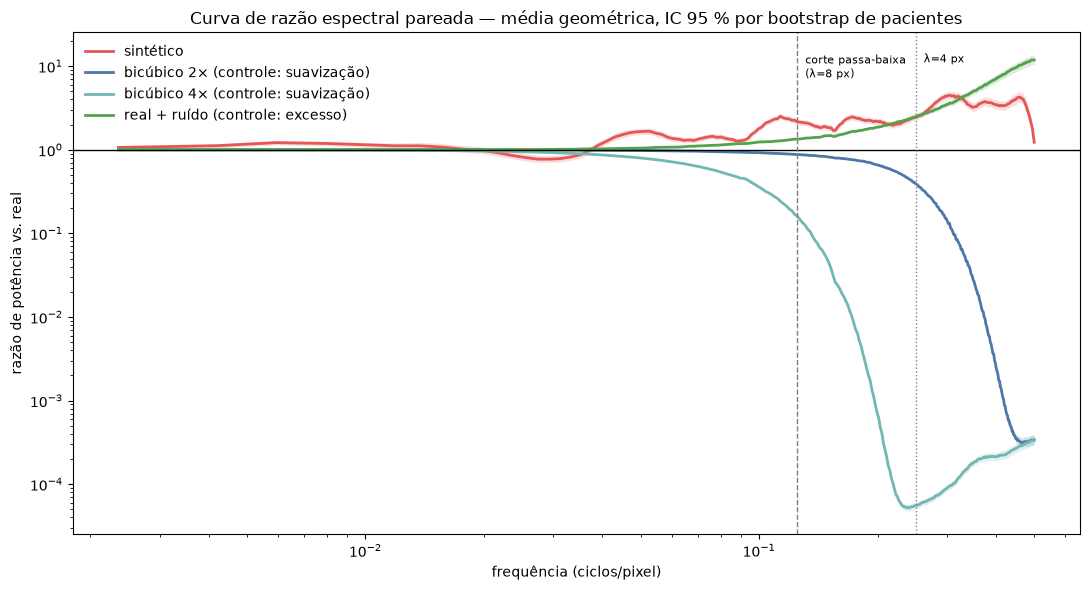

In [4]:
def ratio_matrix(profiles: pd.DataFrame, numer: str, denom: str = "real"):
    """Matriz (pares × bins) de P_numer/P_denom, alinhada por pair_id e bin."""
    a = profiles[profiles["set"] == numer].pivot(index="pair_id", columns="radial_bin", values="power")
    b = profiles[profiles["set"] == denom].pivot(index="pair_id", columns="radial_bin", values="power")
    common = a.index.intersection(b.index)
    a, b = a.loc[common], b.loc[common]
    freq = (profiles[profiles["set"] == denom].groupby("radial_bin")["freq_cpx"].first()
            .reindex(a.columns).to_numpy())
    return (a / b).to_numpy(), freq, common


def plot_ratio(ax, profiles, numer, color, label, groups, n_boot=1000, denom="real"):
    R, freq, pairs = ratio_matrix(profiles, numer, denom)
    g = groups.reindex(pairs).to_numpy()
    est, lo, hi = tstats.geometric_mean_ratio_ci(R, g, n_boot=n_boot, seed=int(cfg["stats"]["seed"]))
    ax.plot(freq, est, color=color, lw=2, label=label)
    ax.fill_between(freq, lo, hi, color=color, alpha=0.2, lw=0)
    return est, freq


fig, ax = plt.subplots(figsize=(11, 6))
curves = {}
for name, color, label in [
    ("syn", "#E45756", "sintético"),
    ("bicubic_2", "#4C78A8", "bicúbico 2× (controle: suavização)"),
    ("bicubic_4", "#72B7B2", "bicúbico 4× (controle: suavização)"),
    ("real_noise", "#54A24B", "real + ruído (controle: excesso)"),
]:
    curves[name], freq = plot_ratio(ax, prof, name, color, label, groups)

ax.axhline(1.0, color="k", lw=1)
ax.axvline(0.125, color="grey", ls="--", lw=1)
ax.axvline(0.25, color="grey", ls=":", lw=1)
ax.text(0.125, ax.get_ylim()[1], "  corte passa-baixa\n  (λ=8 px)", fontsize=8, va="top")
ax.text(0.25, ax.get_ylim()[1], "  λ=4 px", fontsize=8, va="top")
ax.set(xscale="log", yscale="log", xlabel="frequência (ciclos/pixel)",
       ylabel="razão de potência vs. real",
       title="Curva de razão espectral pareada — média geométrica, IC 95 % por bootstrap de pacientes")
ax.legend(frameon=False)
fig.tight_layout()

### Leitura

O sintético e o bicúbico erram em **direções opostas**. É exatamente por isso que o
bicúbico sozinho, como o plano original propunha, não serviria de critério: uma
métrica sensível a alta frequência separa real de bicúbico trivialmente e "passaria"
no teste sem nunca ter demonstrado que enxerga o modo de falha do modelo.

In [5]:
tab = pd.DataFrame({k: v for k, v in curves.items()}, index=np.round(freq, 4))
tab.index.name = "freq (c/px)"
sel = [1, 2, 4, 8, 16, 32, 64, 96, 128, 160, 192, 224, 256]
print("Razão de potência por escala (média geométrica sobre os pares)\n")
print(tab.iloc[[i - 1 for i in sel if i <= len(tab)]].assign(
    **{"λ (px)": [512 / i for i in sel if i <= len(tab)]}).round(3).to_string())

Razão de potência por escala (média geométrica sobre os pares)

               syn  bicubic_2  bicubic_4  real_noise   λ (px)
freq (c/px)                                                  
0.0024       1.064      1.000      0.999       1.000  512.000
0.0042       1.119      1.000      0.999       1.000  256.000
0.0080       1.188      1.000      0.995       1.000  128.000
0.0156       1.077      0.998      0.979       1.001   64.000
0.0313       0.783      0.992      0.917       1.013   32.000
0.0625       1.337      0.967      0.696       1.077   16.000
0.1250       2.158      0.879      0.161       1.345    8.000
0.1875       2.231      0.710      0.002       1.758    5.333
0.2501       2.472      0.392      0.000       2.480    4.000
0.3125       4.441      0.096      0.000       3.715    3.200
0.3750       3.779      0.010      0.000       6.020    2.667
0.4375       3.786      0.000      0.000       9.128    2.286
0.5000       1.230      0.000      0.000      11.875    2.000


## 2. Estratificação: a consistência é a mesma entre os conjuntos?

Três batches de geração, dois tipos de achado, dois splits. Se as curvas se
sobrepõem dentro do IC, o desvio é uma propriedade do modelo; se divergem, é uma
propriedade do batch — e aí um número agregado sobre os 225 pares esconde a diferença.

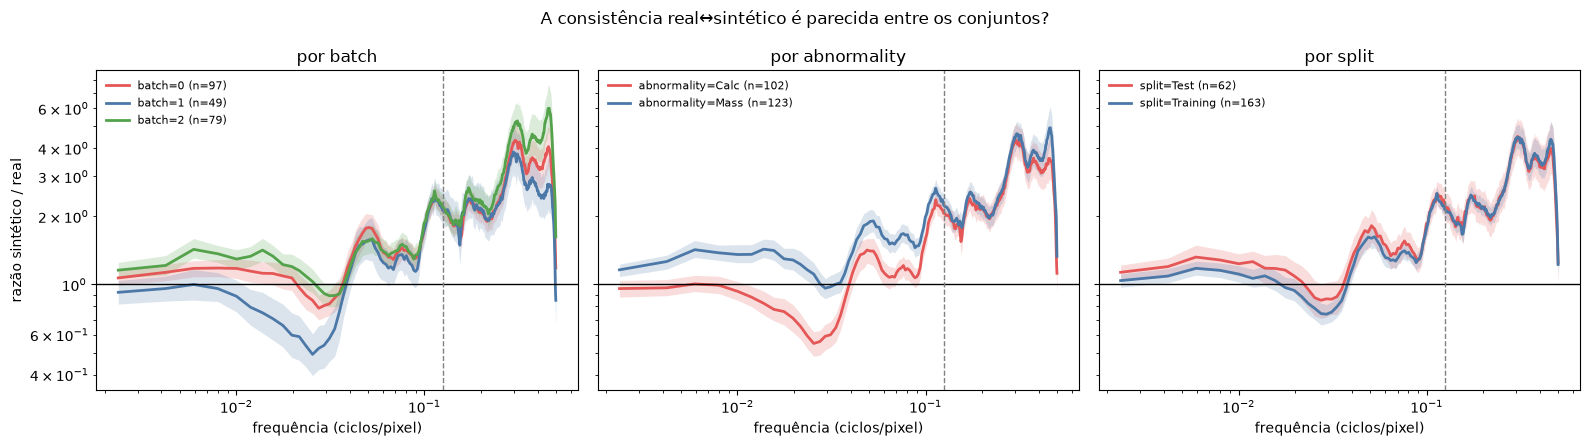

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, strat in zip(axes, ["batch", "abnormality", "split"]):
    for val, color in zip(sorted(man[strat].unique()), ["#E45756", "#4C78A8", "#54A24B"]):
        ids = set(man.loc[man[strat] == val, "pair_id"])
        sub = prof[prof.pair_id.isin(ids)]
        plot_ratio(ax, sub, "syn", color, f"{strat}={val} (n={len(ids)})", groups, n_boot=400)
    ax.axhline(1.0, color="k", lw=1)
    ax.axvline(0.125, color="grey", ls="--", lw=1)
    ax.set(xscale="log", yscale="log", xlabel="frequência (ciclos/pixel)", title=f"por {strat}")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("razão sintético / real")
fig.suptitle("A consistência real↔sintético é parecida entre os conjuntos?")
fig.tight_layout()

## 3. β e as assinaturas periódicas

β descreve a inclinação global; `nyquist_excess` descreve o artefato de geração.
Os dois juntos mostram por que β sozinho não decide nada aqui.

In [7]:
wide = metrics_wide(mets)
show_sets = ["real", "syn", "bicubic_2", "bicubic_4", "real_noise"]
summary = []
for s in show_sets:
    if s not in wide.index.get_level_values("set"):
        continue
    d = wide.xs(s, level="set")
    summary.append({
        "conjunto": s, "β mediana": d["beta"].median(), "β IQR": d["beta"].quantile(.75) - d["beta"].quantile(.25),
        "R² mediana": d["r2_fit"].median(), "nyquist mediana": d["nyquist_excess"].median(),
        "banda λ<4px": d["band_frac_0.25_0.5"].median(),
    })
print(pd.DataFrame(summary).round(3).to_string(index=False))

  conjunto  β mediana  β IQR  R² mediana  nyquist mediana  banda λ<4px
      real      3.068  0.359       0.980            0.611        0.012
       syn      2.867  0.983       0.936            2.675        0.027
 bicubic_2      3.084  0.358       0.980            3.255        0.001
 bicubic_4      3.226  0.360       0.983            1.183        0.000
real_noise      3.017  0.358       0.979            0.315        0.053


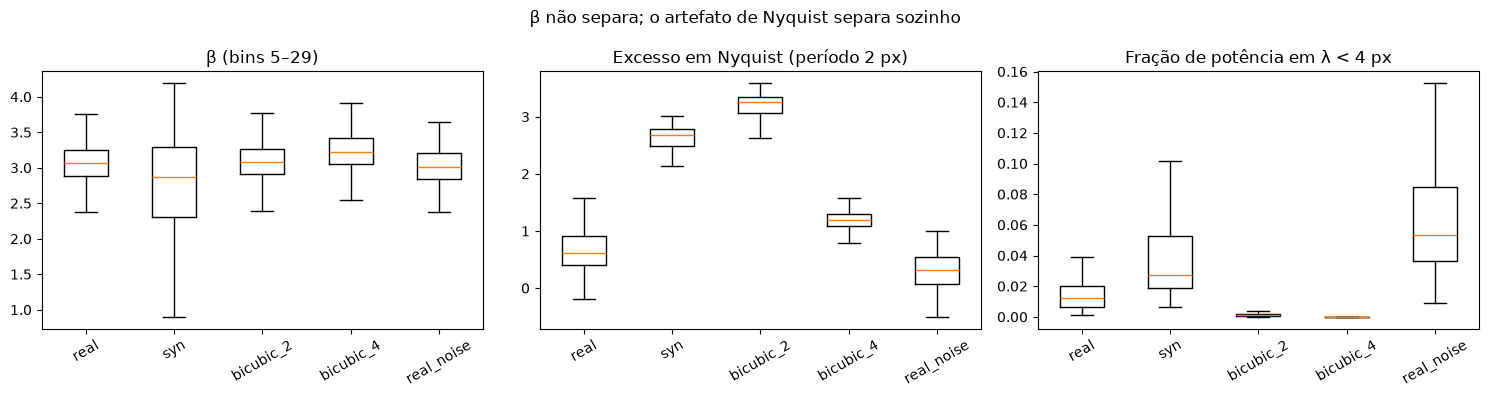

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, title) in zip(axes, [
        ("beta", "β (bins 5–29)"),
        ("nyquist_excess", "Excesso em Nyquist (período 2 px)"),
        ("band_frac_0.25_0.5", "Fração de potência em λ < 4 px")]):
    data = [wide.xs(s, level="set")[col].dropna() for s in show_sets
            if s in wide.index.get_level_values("set")]
    ax.boxplot(data, tick_labels=[s for s in show_sets if s in wide.index.get_level_values("set")],
               showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("β não separa; o artefato de Nyquist separa sozinho")
fig.tight_layout()